# NLP Analysis on Task Management Data
### 3 things we're doing:
- Sentiment Analysis on comments
- Text Classification on tasks (predict category)
- Topic Modeling on task descriptions

In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn scikit-learn nltk vaderSentiment wordcloud



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# install what we need
# run this once
# !pip install pandas scikit-learn nltk vaderSentiment gensim pyLDAvis matplotlib seaborn wordcloud

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load the data
tasks = pd.read_csv('../data/raw/tasks.csv')
comments = pd.read_csv('../data/raw/comments.csv')

print('tasks shape:', tasks.shape)
print('comments shape:', comments.shape)

tasks shape: (10000, 20)
comments shape: (30000, 10)


---
## PART 1 — Sentiment Analysis on Comments
We already have a `Sentiment` column (Positive/Negative/Neutral).
We'll use VADER to predict sentiment ourselves and compare with the existing labels.

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# quick look at the comment text
print(comments['Comment_Text'].value_counts().head(10))

Comment_Text
Customer confirmed the fix.                     1565
Issue reproduced successfully.                  1552
Unable to reproduce the reported issue.         1543
Database migration completed.                   1541
Waiting for QA validation.                      1540
Additional logs have been attached.             1522
Task blocked due to external dependency.        1522
Performance optimization implemented.           1516
Dependency updated successfully.                1500
Fix developed and submitted for code review.    1495
Name: count, dtype: int64


In [7]:
# run vader on each comment
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

comments['vader_sentiment'] = comments['Comment_Text'].apply(get_sentiment)

print(comments[['Comment_Text', 'Sentiment', 'vader_sentiment']].head(10))

                                       Comment_Text Sentiment vader_sentiment
0                   Testing completed successfully.  Positive        Positive
1      Fix developed and submitted for code review.  Positive         Neutral
2      Monitoring the application after deployment.  Positive         Neutral
3                     Database migration completed.  Positive         Neutral
4                     Database migration completed.  Negative         Neutral
5      Monitoring the application after deployment.  Negative         Neutral
6                   API response time has improved.  Positive        Positive
7           Unable to reproduce the reported issue.  Negative         Neutral
8  Changes deployed to the development environment.  Negative         Neutral
9                       Customer confirmed the fix.  Negative         Neutral


In [8]:
# how accurate is vader vs the existing labels?
from sklearn.metrics import classification_report

print(classification_report(comments['Sentiment'], comments['vader_sentiment']))

              precision    recall  f1-score   support

    Negative       0.34      0.05      0.09     10012
     Neutral       0.34      0.60      0.43     10114
    Positive       0.33      0.35      0.34      9874

    accuracy                           0.34     30000
   macro avg       0.34      0.33      0.29     30000
weighted avg       0.34      0.34      0.29     30000



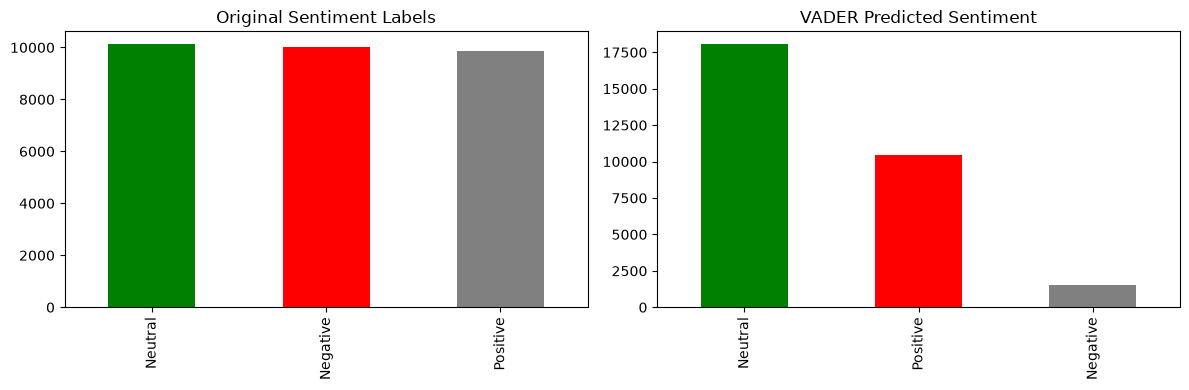

In [9]:
# plot the sentiment distribution — original vs vader
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comments['Sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red', 'gray'])
axes[0].set_title('Original Sentiment Labels')
axes[0].set_xlabel('')

comments['vader_sentiment'].value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red', 'gray'])
axes[1].set_title('VADER Predicted Sentiment')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/charts/sentiment_comparison.png')
plt.show()

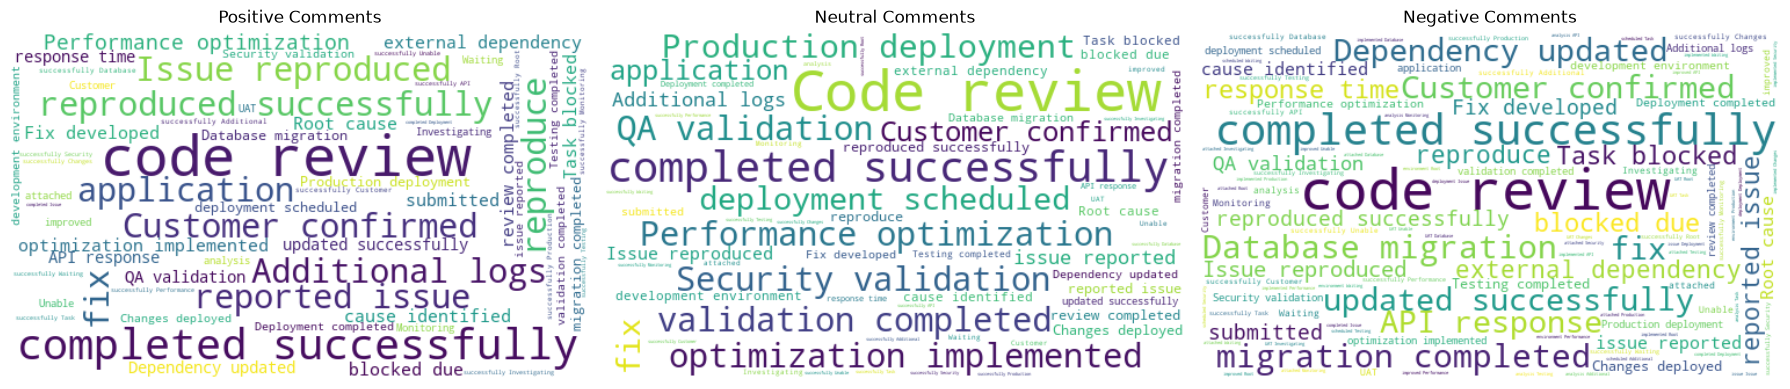

In [10]:
# wordcloud for each sentiment
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, sentiment in enumerate(['Positive', 'Neutral', 'Negative']):
    text = ' '.join(comments[comments['Sentiment'] == sentiment]['Comment_Text'].astype(str))
    wc = WordCloud(width=500, height=300, background_color='white').generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{sentiment} Comments')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../outputs/charts/sentiment_wordclouds.png')
plt.show()

---
## PART 2 — Text Classification (Predict Task Category)
We'll use Task_Title + Task_Description to predict the Category (Bug, Feature, DevOps, etc.)
Using TF-IDF + Logistic Regression — simple and works great.

In [11]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

nltk.download('stopwords')
stop_words = stopwords.words('english')

# combine title + description into one text column
tasks['text'] = tasks['Task_Title'].astype(str) + ' ' + tasks['Task_Description'].astype(str)

print('Categories:', tasks['Category'].value_counts())

Categories: Category
Testing             1048
Documentation       1028
UI/UX               1028
Support             1023
Feature             1011
Enhancement          987
Data Engineering     980
DevOps               972
Security             968
Bug                  955
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# split data
X = tasks['text']
y = tasks['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 8000, Test size: 2000


In [13]:
# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF matrix shape:', X_train_tfidf.shape)

TF-IDF matrix shape: (8000, 5000)


In [14]:
# train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

             Bug       1.00      1.00      1.00       201
Data Engineering       1.00      1.00      1.00       206
          DevOps       1.00      1.00      1.00       185
   Documentation       1.00      1.00      1.00       199
     Enhancement       1.00      1.00      1.00       196
         Feature       1.00      1.00      1.00       194
        Security       1.00      1.00      1.00       199
         Support       1.00      1.00      1.00       181
         Testing       1.00      1.00      1.00       229
           UI/UX       1.00      1.00      1.00       210

        accuracy                           1.00      2000
       macro avg       1.00      1.00      1.00      2000
    weighted avg       1.00      1.00      1.00      2000



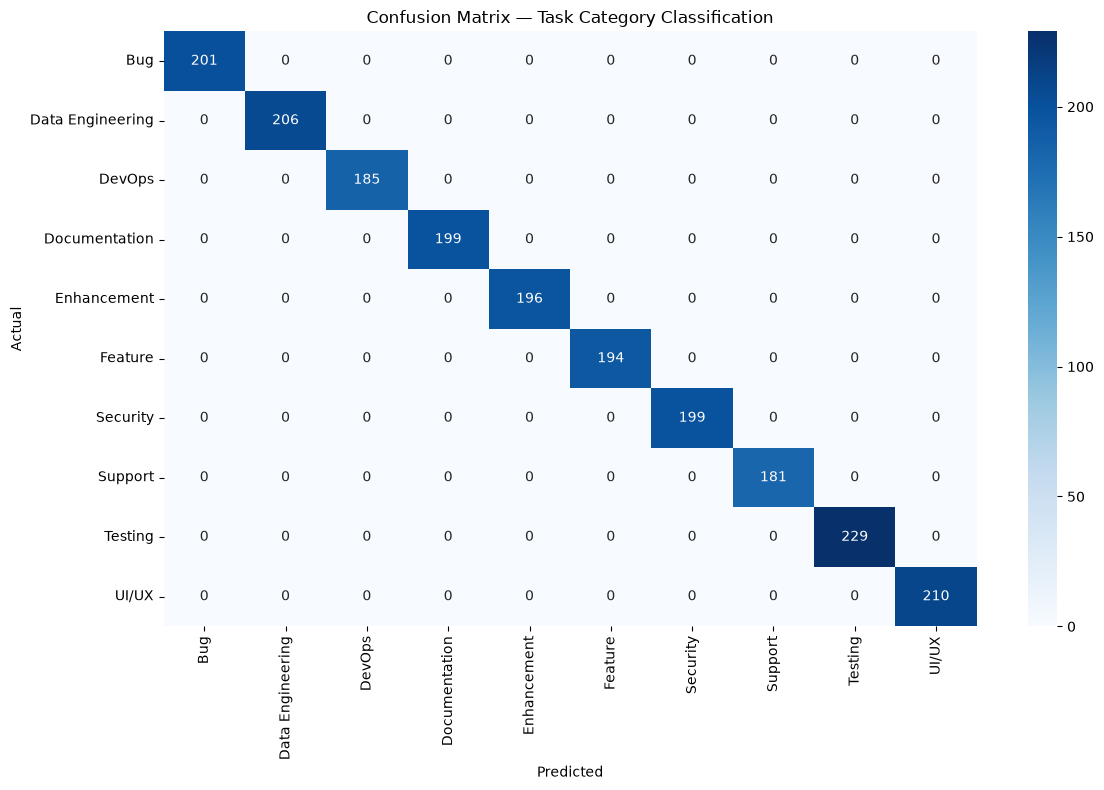

In [15]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title('Confusion Matrix — Task Category Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/charts/classification_confusion_matrix.png')
plt.show()

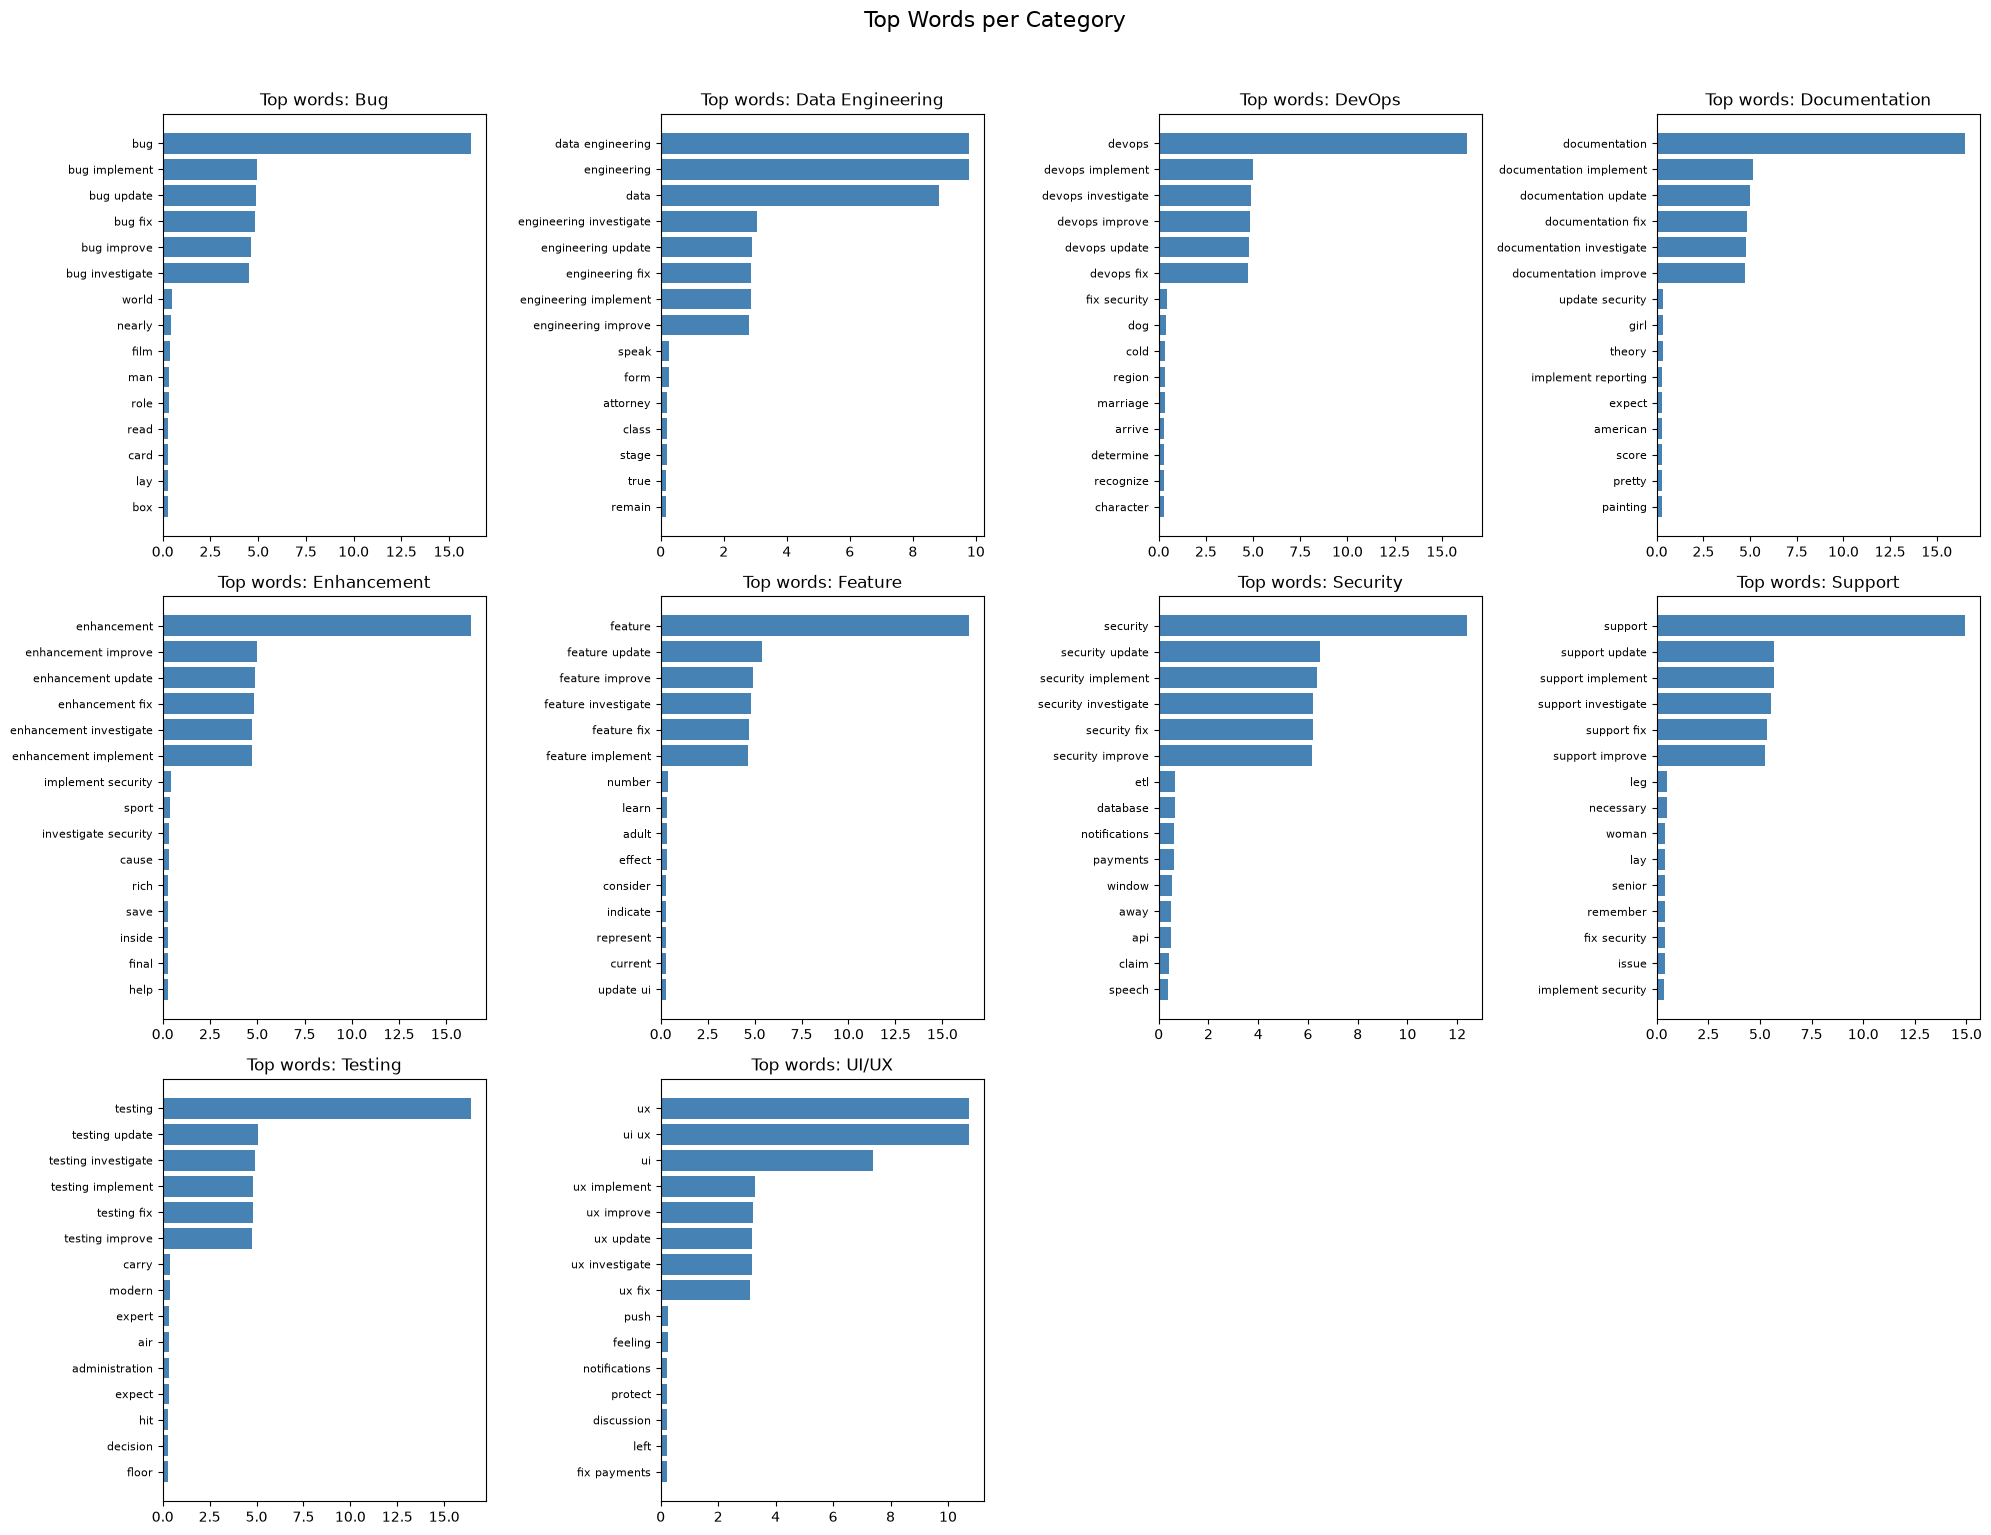

In [16]:
# top words per category — what words are most important for each category?
import numpy as np

feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, category in enumerate(model.classes_):
    top_indices = np.argsort(model.coef_[i])[-15:]
    top_words = [feature_names[j] for j in top_indices]
    top_scores = [model.coef_[i][j] for j in top_indices]
    
    axes[i].barh(top_words, top_scores, color='steelblue')
    axes[i].set_title(f'Top words: {category}')
    axes[i].tick_params(axis='y', labelsize=8)

# hide any extra subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Words per Category', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/top_words_per_category.png', bbox_inches='tight')
plt.show()

---
## PART 3 — Topic Modeling on Task Descriptions
We'll use LDA (Latent Dirichlet Allocation) to find hidden topics in task descriptions.
No labels needed — fully unsupervised.

In [17]:
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# clean the text a bit
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove numbers and punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tasks['clean_desc'] = tasks['Task_Description'].apply(clean_text)

print(tasks['clean_desc'].head(3))

0    house answer start behind old travel democrat ...
1    way officer however wish another teach face ce...
2    recognize each off modern themselves role expl...
Name: clean_desc, dtype: str


In [18]:
# vectorize using count vectorizer (LDA needs raw counts, not TF-IDF)
cv = CountVectorizer(max_features=3000, stop_words='english', min_df=5)
doc_term_matrix = cv.fit_transform(tasks['clean_desc'])

print('Doc-term matrix shape:', doc_term_matrix.shape)

Doc-term matrix shape: (10000, 763)


In [19]:
# train LDA with 8 topics
NUM_TOPICS = 8

lda = LatentDirichletAllocation(n_components=NUM_TOPICS, random_state=42, max_iter=20)
lda.fit(doc_term_matrix)

print('LDA training done!')

LDA training done!


In [20]:
# print top words for each topic
vocab = cv.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = [vocab[i] for i in topic.argsort()[-10:][::-1]]
    print(f'Topic {topic_idx + 1}: {" | ".join(top_words)}')

Topic 1: standard | white | floor | collection | quickly | space | training | series | quite | condition
Topic 2: thousand | effort | produce | drive | result | special | rock | office | daughter | century
Topic 3: chair | hear | religious | air | boy | suddenly | story | plant | good | product
Topic 4: modern | contain | rate | article | create | play | thank | early | catch | time
Topic 5: phone | culture | box | like | finally | fight | certainly | wind | imagine | machine
Topic 6: reflect | financial | sport | today | dog | politics | state | kitchen | argue | performance
Topic 7: computer | compare | support | rise | difficult | child | inside | stock | recently | grow
Topic 8: newspaper | risk | figure | address | chance | spend | food | pick | song | leg


In [21]:
# assign dominant topic to each task
topic_probs = lda.transform(doc_term_matrix)
tasks['dominant_topic'] = topic_probs.argmax(axis=1) + 1  # +1 so topics start from 1

print(tasks['dominant_topic'].value_counts())

dominant_topic
6    1333
1    1322
3    1300
7    1294
8    1266
4    1226
5    1206
2    1053
Name: count, dtype: int64


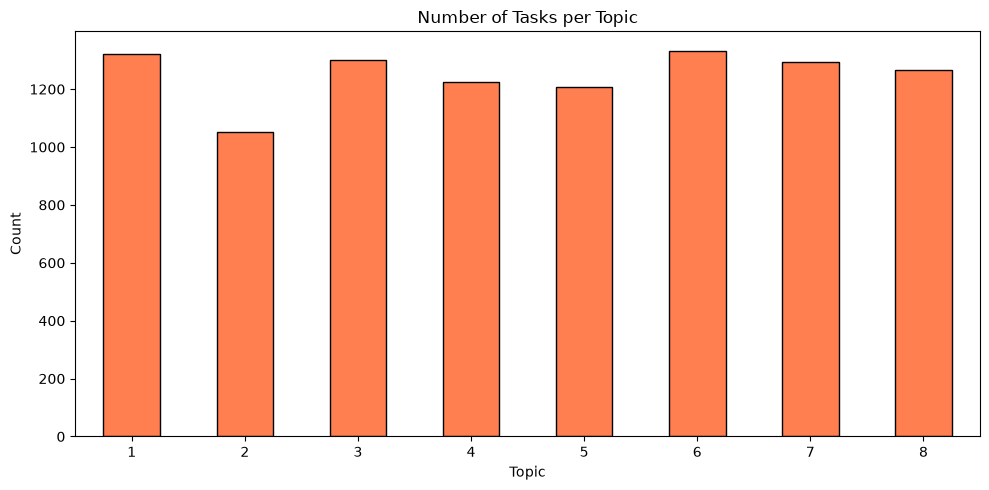

In [22]:
# plot topic distribution
plt.figure(figsize=(10, 5))
tasks['dominant_topic'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Number of Tasks per Topic')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/charts/topic_distribution.png')
plt.show()

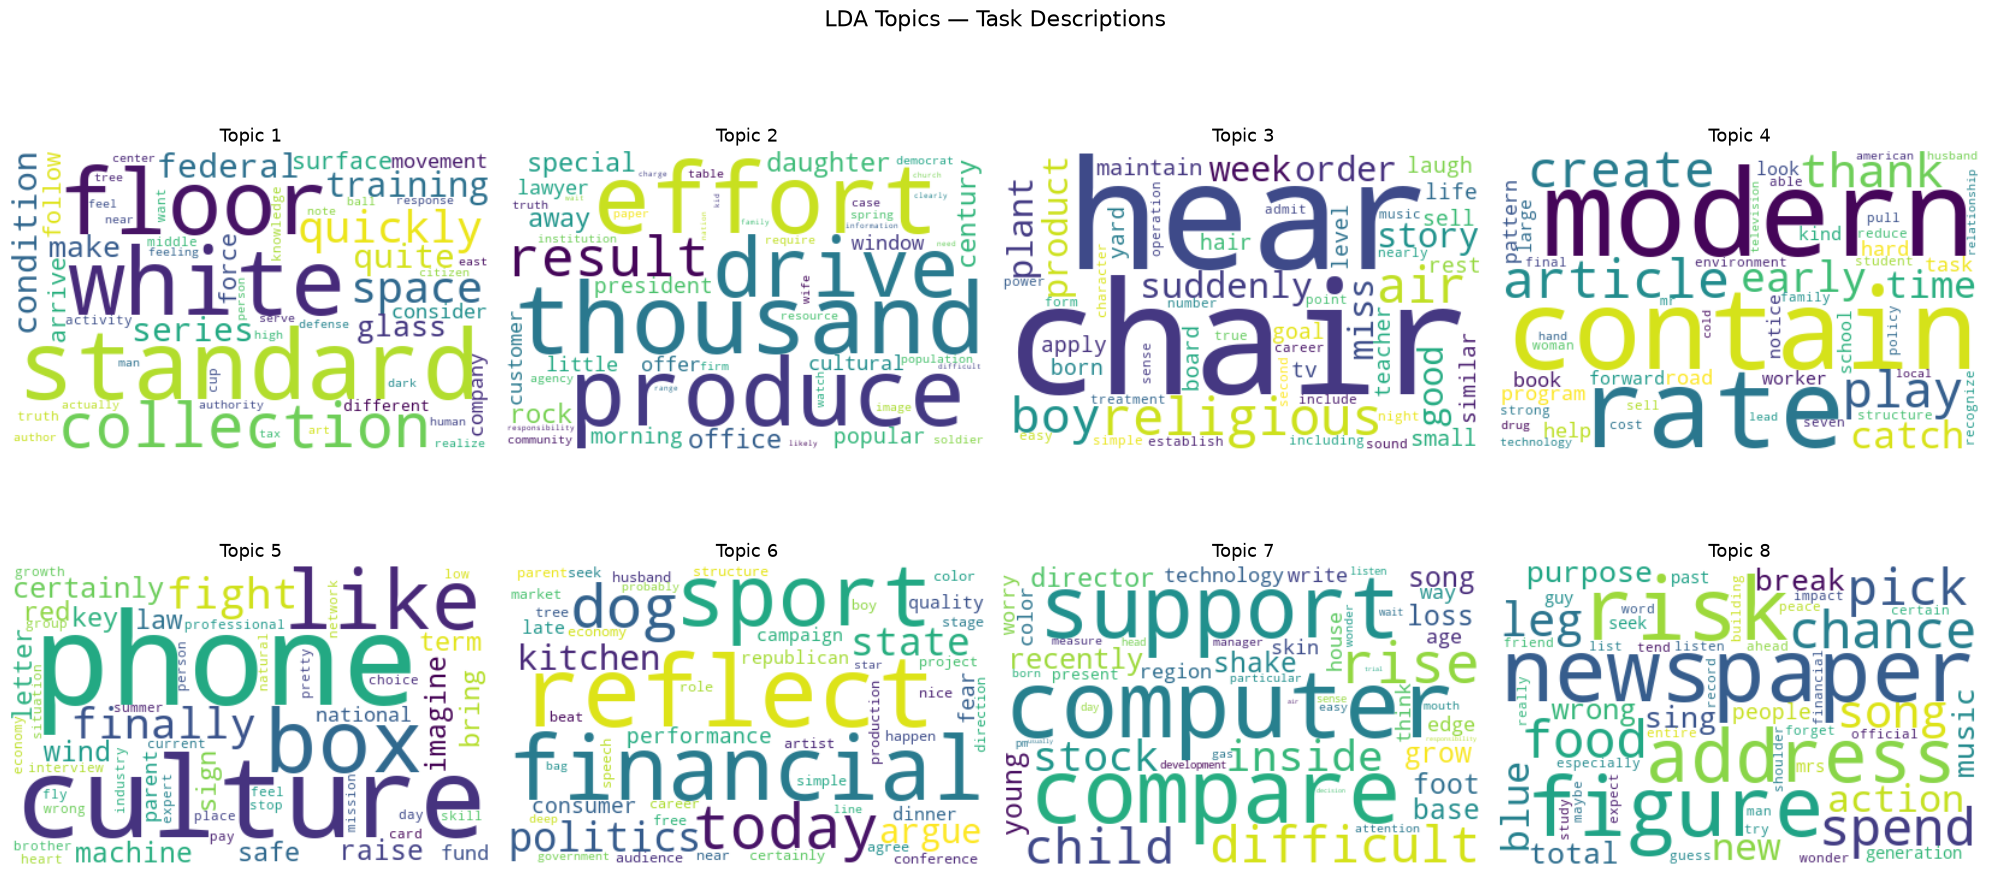

In [23]:
# visualize topics as wordclouds
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda.components_):
    word_freq = {vocab[i]: topic[i] for i in topic.argsort()[-50:]}
    wc = WordCloud(width=400, height=250, background_color='white').generate_from_frequencies(word_freq)
    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontsize=13)
    axes[topic_idx].axis('off')

plt.suptitle('LDA Topics — Task Descriptions', fontsize=16)
plt.tight_layout()
plt.savefig('../outputs/charts/topic_wordclouds.png')
plt.show()

<Figure size 1400x600 with 0 Axes>

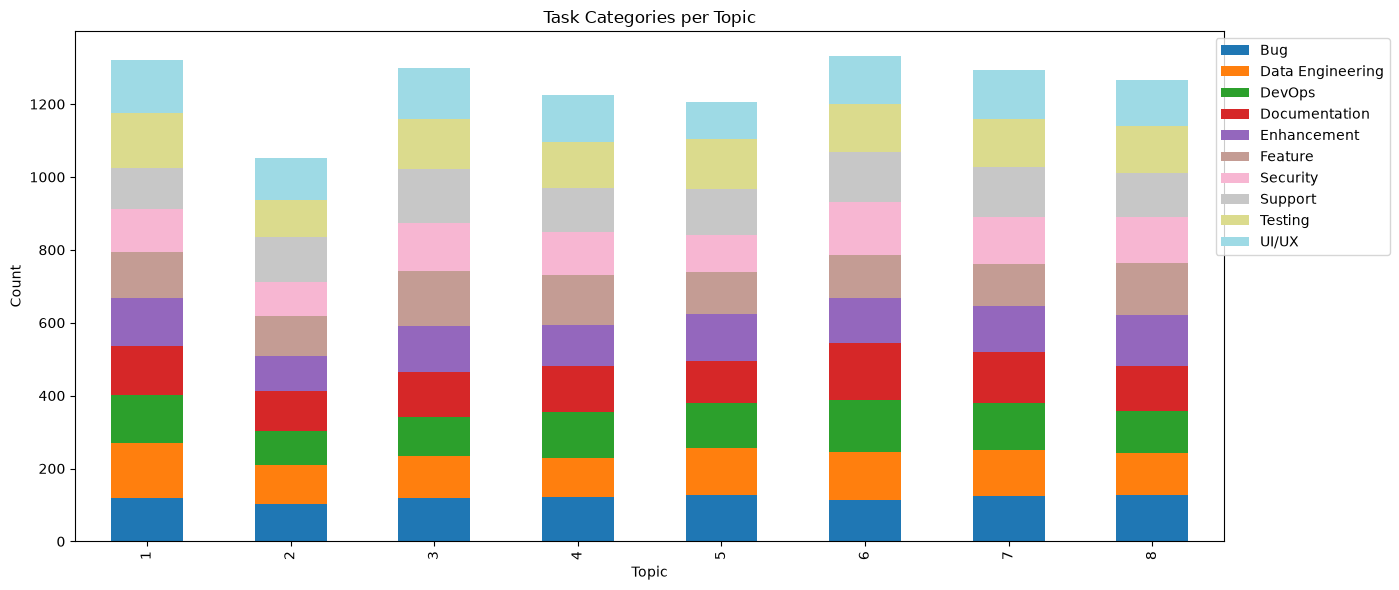

In [24]:
# see which categories fall under which topics
topic_category = tasks.groupby(['dominant_topic', 'Category']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
topic_category.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.title('Task Categories per Topic')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig('../outputs/charts/topic_vs_category.png', bbox_inches='tight')
plt.show()

---
## Summary

| Part | What we did | Result |
|------|------------|--------|
| Sentiment Analysis | VADER on comment text, compared with existing labels | See classification report |
| Text Classification | TF-IDF + Logistic Regression to predict task category | See confusion matrix |
| Topic Modeling | LDA on task descriptions to find hidden topics | 8 topics discovered |